In [1]:
!pip install soundfile numpy matplotlib

   ---------------------------------------- 0.0/1.0 MB ? eta -:--:--
   ---------------------------------------- 0.0/1.0 MB ? eta -:--:--
   -------------------- ------------------- 0.5/1.0 MB 2.4 MB/s eta 0:00:01
   ------------------------------ --------- 0.8/1.0 MB 2.0 MB/s eta 0:00:01
   ---------------------------------------- 1.0/1.0 MB 1.6 MB/s eta 0:00:00


--- Loudness Comparison ---
File 1 (openloop.wav): -20.49 dBFS
File 2 (foc.wav): -19.41 dBFS

Result: File 2 is louder by 1.08 dB.


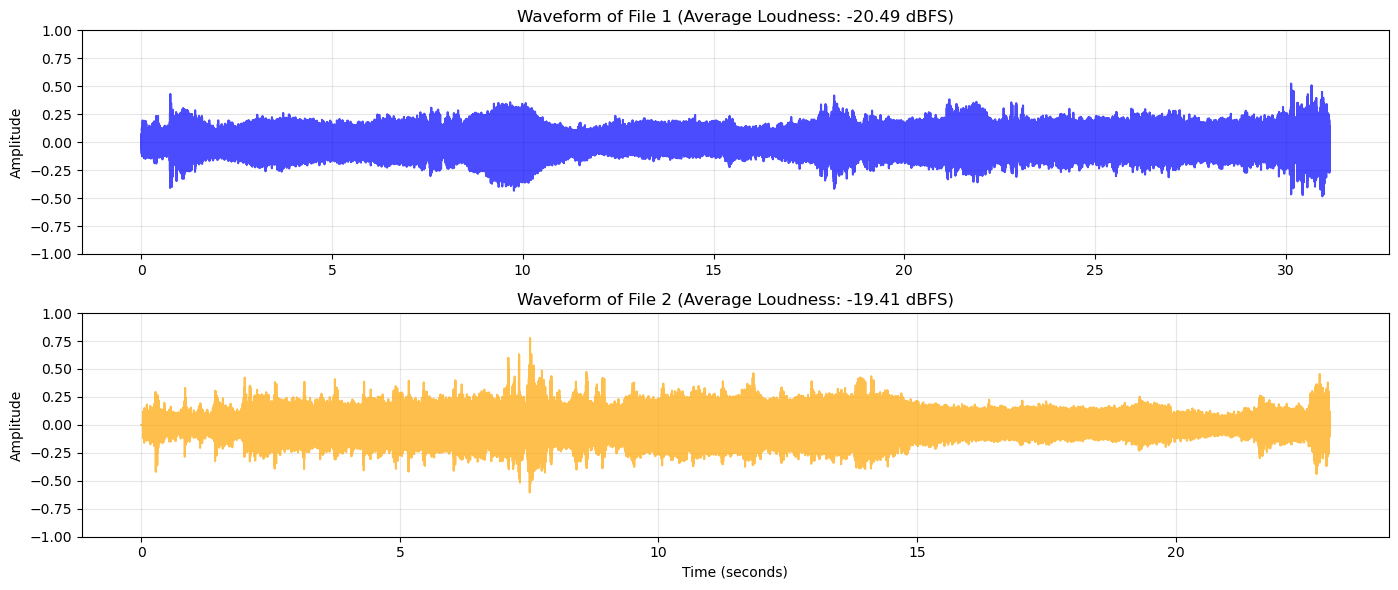

In [3]:
import soundfile as sf
import numpy as np
import matplotlib.pyplot as plt

def analyze_loudness(file_path):
    """Reads a WAV file and calculates its average loudness in dBFS."""
    # soundfile automatically reads audio as float64 between -1.0 and 1.0
    data, sample_rate = sf.read(file_path)
    
    # Convert stereo to mono by averaging the channels
    if len(data.shape) > 1:
        data = data.mean(axis=1)
        
    # 1. Calculate RMS (Root Mean Square) - the average signal power
    rms = np.sqrt(np.mean(data**2))
    
    # 2. Convert to Decibels relative to Full Scale (dBFS)
    # Note: 0 dBFS is maximum clipping limit. Normal audio is always negative.
    dbfs = 20 * np.log10(rms) if rms > 0 else -np.inf
    
    return dbfs, data, sample_rate

# --- Setup your files here ---
file1_path = 'openloop.wav' # Replace with your first file name
file2_path = 'foc.wav' # Replace with your second file name

# Process both files
db1, data1, sr1 = analyze_loudness(file1_path)
db2, data2, sr2 = analyze_loudness(file2_path)

# --- Output the numerical results ---
print(f"--- Loudness Comparison ---")
print(f"File 1 ({file1_path}): {db1:.2f} dBFS")
print(f"File 2 ({file2_path}): {db2:.2f} dBFS")

if db1 > db2:
    print(f"\nResult: File 1 is louder by {db1 - db2:.2f} dB.")
elif db2 > db1:
    print(f"\nResult: File 2 is louder by {db2 - db1:.2f} dB.")
else:
    print("\nResult: Both files are exactly the same volume.")

# --- Visualize the waveforms ---
plt.figure(figsize=(14, 6))

# Subplot 1
plt.subplot(2, 1, 1)
time1 = np.linspace(0, len(data1) / sr1, num=len(data1))
plt.plot(time1, data1, color='blue', alpha=0.7)
plt.title(f"Waveform of File 1 (Average Loudness: {db1:.2f} dBFS)")
plt.ylabel("Amplitude")
plt.ylim(-1, 1)
plt.grid(True, alpha=0.3)

# Subplot 2
plt.subplot(2, 1, 2)
time2 = np.linspace(0, len(data2) / sr2, num=len(data2))
plt.plot(time2, data2, color='orange', alpha=0.7)
plt.title(f"Waveform of File 2 (Average Loudness: {db2:.2f} dBFS)")
plt.xlabel("Time (seconds)")
plt.ylabel("Amplitude")
plt.ylim(-1, 1)
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()